# 02 – Feature Analysis

Feature importance, variance filtering, delta features, and dimensionality reduction
for the EmoPairCompete dataset.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')
%matplotlib inline

In [2]:
# Load all CSV files — column names are read directly from each file's header
data_dir = Path('../data/raw/data')

csv_files = glob.glob(str(data_dir / '**/*.csv'), recursive=True)
dfs = {}
for f in sorted(csv_files):
    key = Path(f).stem
    dfs[key] = pd.read_csv(f, index_col=0)
    print(f"{Path(f).relative_to(data_dir)}  →  {dfs[key].shape}")

df = dfs['HR_data'].dropna()
print(f'\nDataset after dropping missing: {df.shape[0]} rows, {df.shape[1]} columns')

HR_data.csv  →  (312, 67)
dataset/D1_1/ID_1/round_1/phase1/BVP.csv  →  (28624, 2)
dataset/D1_1/ID_1/round_1/phase1/EDA.csv  →  (1789, 2)
dataset/D1_1/ID_1/round_1/phase1/HR.csv  →  (448, 2)
dataset/D1_1/ID_1/round_1/phase1/TEMP.csv  →  (1789, 2)
dataset/D1_1/ID_1/round_1/phase1/response.csv  →  (1, 15)
dataset/D1_1/ID_1/round_1/phase2/BVP.csv  →  (25081, 2)
dataset/D1_1/ID_1/round_1/phase2/EDA.csv  →  (1567, 2)
dataset/D1_1/ID_1/round_1/phase2/HR.csv  →  (392, 2)
dataset/D1_1/ID_1/round_1/phase2/TEMP.csv  →  (1567, 2)
dataset/D1_1/ID_1/round_1/phase2/response.csv  →  (1, 16)
dataset/D1_1/ID_1/round_1/phase3/BVP.csv  →  (23691, 2)
dataset/D1_1/ID_1/round_1/phase3/EDA.csv  →  (1480, 2)
dataset/D1_1/ID_1/round_1/phase3/HR.csv  →  (370, 2)
dataset/D1_1/ID_1/round_1/phase3/TEMP.csv  →  (1480, 2)
dataset/D1_1/ID_1/round_1/phase3/response.csv  →  (1, 15)
dataset/D1_1/ID_1/round_2/phase1/BVP.csv  →  (19565, 2)
dataset/D1_1/ID_1/round_2/phase1/EDA.csv  →  (1223, 2)
dataset/D1_1/ID_1/round_2/pha

In [3]:
# Identify biosignal columns dynamically — numeric, excluding metadata
meta_cols = ['Round', 'Phase', 'Individual', 'Puzzler', 'Cohort']
numeric_cols = df.select_dtypes(include='number').columns.tolist()
biosignal_cols = [c for c in numeric_cols if c not in meta_cols]

# Variance-based feature selection
variances = df[biosignal_cols].var()
high_var_cols = variances[variances > 0.01].index.tolist()
print(f'Features passing variance threshold: {len(high_var_cols)}')

Features passing variance threshold: 47


In [4]:
# Delta features: difference between phase values per participant/round
phases = df['Phase'].unique()
print(f'Phases: {phases}')

# Pivot to wide format and compute deltas between consecutive phases
df_pivot = df.pivot_table(index=['Individual', 'Round'], columns='Phase', values=high_var_cols)
df_pivot.columns = ['_'.join(str(c) for c in col) for col in df_pivot.columns]

delta_cols = []
if 'phase1' in phases and 'phase3' in phases:
    for col in high_var_cols:
        delta_name = f'{col}_delta'
        if f'{col}_phase3' in df_pivot.columns and f'{col}_phase1' in df_pivot.columns:
            df_pivot[delta_name] = df_pivot[f'{col}_phase3'] - df_pivot[f'{col}_phase1']
            delta_cols.append(delta_name)

print(f'Delta columns: {len(delta_cols)}')
df_pivot[delta_cols].describe()

Phases: ['phase3' 'phase2' 'phase1']
Delta columns: 47


,HR_TD_Mean_delta,HR_TD_Median_delta,HR_TD_std_delta,HR_TD_Min_delta,HR_TD_Max_delta,HR_TD_AUC_delta,HR_TD_Kurtosis_delta,HR_TD_Skew_delta,HR_TD_Slope_min_delta,HR_TD_Slope_max_delta,...,upset_delta,hostile_delta,alert_delta,ashamed_delta,inspired_delta,nervous_delta,attentive_delta,afraid_delta,active_delta,determined_delta
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,100.000000,100.00,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,-1.598874,-1.767300,-1.224218,1.040000,-4.305500,-307.457250,-0.365817,0.155684,0.127225,-0.193438,...,0.180000,0.02,-0.100000,0.070000,-0.030000,-0.220000,-0.220000,-0.030000,0.020000,-0.250000
std,10.566197,11.483393,6.925742,7.892422,22.487976,4179.246531,2.620970,1.146711,0.551027,0.743110,...,0.538985,0.20,0.689019,0.573048,0.936952,0.612661,0.949003,0.222702,0.994734,1.242147
min,-69.996538,-86.180000,-27.469140,-26.590000,-87.520000,-20996.715000,-6.915924,-2.263294,-1.527500,-5.365000,...,-1.000000,-1.00,-2.000000,-3.000000,-4.000000,-2.000000,-3.000000,-2.000000,-3.000000,-3.000000
25%,-4.871152,-4.075000,-3.583691,-3.635000,-13.412500,-1936.710000,-1.166237,-0.611451,-0.161250,-0.256875,...,0.000000,0.00,-0.250000,0.000000,0.000000,-1.000000,-1.000000,0.000000,-1.000000,-1.000000
50%,-1.137037,-0.875000,-0.464492,0.530000,-0.585000,-288.835000,-0.383488,-0.008477,0.045000,-0.037500,...,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.876495,2.441250,1.438375,5.787500,6.727500,1854.372500,0.582257,0.852919,0.335625,0.099375,...,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,18.254533,19.445000,28.137633,20.720000,83.940000,9355.070000,13.494038,3.390101,1.855000,1.127500,...,2.000000,1.00,1.000000,2.000000,3.000000,2.000000,3.000000,0.000000,3.000000,4.000000


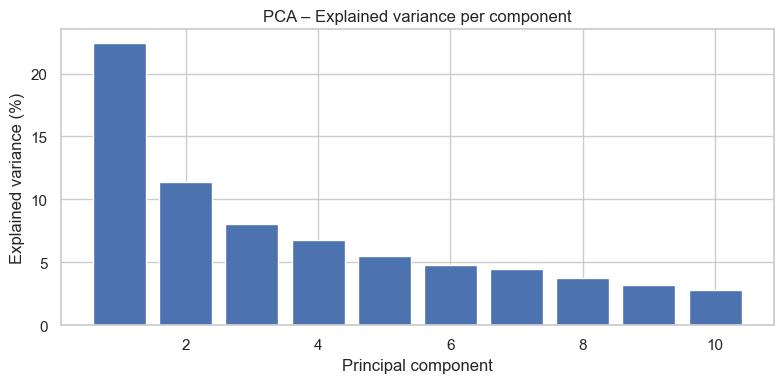

In [5]:
# PCA on normalised biosignal features
X = df[high_var_cols].dropna()
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=10)
pca.fit(X_scaled)

plt.figure(figsize=(8, 4))
plt.bar(range(1, 11), pca.explained_variance_ratio_ * 100)
plt.xlabel('Principal component')
plt.ylabel('Explained variance (%)')
plt.title('PCA – Explained variance per component')
plt.tight_layout()
plt.savefig('../results/figures/pca_variance.png', dpi=150)
plt.show()